In [1]:
%reload_ext autoreload
%autoreload 2

### all the imports I could need
import os
os.environ['OMP_NUM_THREADS'] = "64"    # stop antisocial behaviour on shared cluster

# file ops
from datetime import datetime
from pathlib import Path
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings(action="ignore", category=RuntimeWarning)

# spatial
import xarray as xa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import rioxarray
import cartopy.crs as ccrs

# machine learning
from dask.distributed import get_client, Client, LocalCluster, SSHCluster
from concurrent.futures import ThreadPoolExecutor
import xgboost as xgb

# custom
from coralshift.utils import file_ops, config, utils, thresholding
from coralshift.utils.config import Config
from coralshift.dataloading import get_data
from coralshift.machine_learning import static_models, run_model, ml_results
from coralshift.processing import ml_processing
from coralshift.processing import spatial_data

from tqdm.auto import tqdm
import cmipper
from graphpy import spatial as graphpy_spatial
from graphpy import colours as graphpy_colours
import cmipper.utils as cmipper_utils

# data fps
gt_data_dir = config.gt_data_dir
config_info = file_ops.read_yaml(config.config_dir / "config_test.yaml")
config_class = Config(config_info)

cs_lats = [-30, 0]
cs_lons = [130, 170]

/maps/rt582/miniforge3/envs/shiftpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Communicating computational challenges

0. <ins>What's the best way to lay out problematic code to walk through with someone?</ins>
    - Especially wrt linking it to a complicated pipeline

![desired_threshold_behaviour](/maps/rt582/coralshift/notebooks/wip/desired_threshold.jpg)

~~strikethrough~~ sections denote current functionality, with desired improvements in <font color="red">red</font>.

## Acquiring CMIP6 data

- Huge number of models, variables, ensemble runs.
    - A challenge to find which models contain the necessary variables in both hind-cast and forecast. <ins>*Is there an existing tool to determine (perhaps with nice visualisation) this?*</ins>
- Prohibitively large volume of data.
    - Only require top few levels – <ins>*is it possible to download only these levels?*</ins>
- Can't get `wget` scripts or `glodap` to work.
    - Looks like an unimplemented (`glodap`) or auth (`wget`) issue.
    - Currently using `esgpull`
    - Should look into [`esgf-pyclient`](https://pypi.org/project/esgf-pyclient/)

## Generating raster for high-resolution shapefile

Ground truth, coral reef presence/absence (binary) is a shapefile at nominal 30m resolution. To rasterise, I use `rasterio`'s `rasterize` (in `coralshift.dataloading.get_data`'s `rasterize_geodf`). In the end I want a 15/3600" reef density (number of reef cells/area of cell). But rasterizing at native (30m) resolution globally is prohibitively slow. It's just about tractable at higher resolutions, but the result is different:

![impact_of_rasterisation_resolution_on_density](/maps/rt582/coralshift/notebooks/wip/rasterisation_resolution_impact.png)

Currently just doing at 15" and normalising between 0 and 1. Distributions are noticeably different, however. <ins>Any suggestions on making it tractable to compute raster at native resolution and *afterwards* calculate density at the lower resolution?</ins>

## Handling data at ~450m resolution globally

1. Downsampling (biliear interpolation) coarse-resolution climate data and upsampling (presence-absence mapped to density over area via averaging) reef map to happy middle-ground of global bathymetry via `rioxarray`.
    - <ins>Applying a shallow-water mask never completes.</ins> SOLVED – compute coarse with max depth values for square, then apply high-resolution mask
    - Fine for bathymetry and reef map, problematic with ~2000 timesteps of climate data (for PAR): takes a long time

2. <ins>Calculating percentiles rather than min/max?</ins> ANSWERED
    - Use [`python cdo`](https://code.mpimet.mpg.de/projects/cdo/wiki/Cdo%7Brbpy%7D) – much faster than xarray operations

3. <ins>Scaling AUC calculation for high-resolution timeseries</ins>
    - Necessary for PAR computation (since function of bathymetry). <ins>Believe also necessary for other coarse-resolution environmental data, since percentile computation followed by linear downsampling ≠ linear downsampling followed by percentile computation.

4. <ins>How to connect to `dask` dashboard on ssh server?</ins> ANSWERED
    - Following url gives 'site can't be reached' error.
    - Add port e.g. `8787` to manually to VSCode (bottom taskbar), then open in browser or preview in editor

5. <ins>Best practice for spawning dask clients?</ins> Can shutdown but seemingly not remove connection to port e.g.
```UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33887 instead


In [ ]:
### 1 Shallow water mask 

from dask.diagnostics import ProgressBar

og_bath = spatial_data.process_xa_d(xa.open_dataset(config.bathymetry_dir / "gebco/GEBCO_2023_n90-0_s90-0_w180-0_e180-0.nc", chunks="auto"))
# drop
og_bath = og_bath.drop_vars(["crs"])
og_bath = og_bath.astype("float32")
# bathymetry mask
bathymetry_mask = og_bath.elevation.where(
    (og_bath.elevation > -200) & (og_bath.elevation < 10), np.nan)

with ProgressBar():
    bathymetry_mask = bathymetry_mask.compute()

[########################################] | 100% Completed | 79.16 s


In [10]:
# load e.g. environmental data for PAR calculation
AWI_data_dir = Path("/maps/rt582/cmipper/.esgpull/data/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/historical/r1i1p1f1/Omon")
rsdo_historical = spatial_data.process_xa_d(xa.open_mfdataset((AWI_data_dir / "rsdo/gn/v20181218/remapped").glob("*.nc"), chunks="auto"))
sub_rsdo = rsdo_historical.isel(time=slice(0,1))
sub_rsdo

<xarray.Dataset> Size: 4MB
Dimensions:    (time: 1, longitude: 1440, latitude: 720)
Coordinates:
  * time       (time) datetime64[ns] 8B 1850-01-16T12:00:00
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * latitude   (latitude) float64 6kB -90.0 -89.75 -89.5 ... 89.25 89.5 89.75
Data variables:
    rsdo       (time, latitude, longitude) float32 4MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
Attributes: (12/43)
    CDI:                       Climate Data Interface version 2.4.0 (https://...
    Conventions:               CF-1.7 CMIP-6.2
    source:                    AWI-CM-1-1-MR
    institution:               Alfred Wegener Institute, Helmholtz Centre for...
    activity_id:               CMIP
    creation_date:             2018-12-18T12:00:00Z
    ...                        ...
    parent_source_id:          AWI-CM-1-1-MR
    parent_time_units:         days since 2401-1-1
    parent_variant_label:      r1i1p1f1
    history:                   Sun Nov 24 11:28:02 2024: cdo -P 128 remapcon,...
    CDO:                       Climate Data Operators version 2.4.0 (https://...
    cdo_openmp_thread_number:  128

In [11]:
# coarsen bathymetry mask to environmental dataset, retaining maximum values (shallowest water)
# ie. if this max value is outside of shallow water mask, all the values in the cell will be
n_lats = 720
n_lons = 1440

coarse_bathymetry = bathymetry_mask.coarsen(
    longitude=int(len(bathymetry_mask.longitude.values) / n_lons),
    latitude=int(len(bathymetry_mask.latitude.values) / n_lats)).min()

# interpolate to environmental dataset grid
coarse_bathymetry = coarse_bathymetry.interp(
    longitude=sub_rsdo.longitude,
    latitude=sub_rsdo.latitude,
    method="nearest"
)

# mask rsdo data (conservatively)
masked_rsdo = sub_rsdo.where(~coarse_bathymetry.isnull())

In [ ]:
# upsample masked rsdo to og bathymetry resolution (0.25º to ~0.04º)
# would like bilinear interpolation: but this takes a prohibitively-long time even for a single timestep (let alone ~1000)
# QQQ: is there a way to do this more efficiently? Parallelisation? Different library?
upsampled_rsdo = masked_rsdo.interp(latitude=og_bath.latitude, longitude=og_bath.longitude, method="linear")    # N.B. NN much quicker than linear (for single timestep: ~5s vs ~350s)
with ProgressBar():
    upsampled_rsdo = upsampled_rsdo.compute()

[########################################] | 100% Completed | 349.89 s


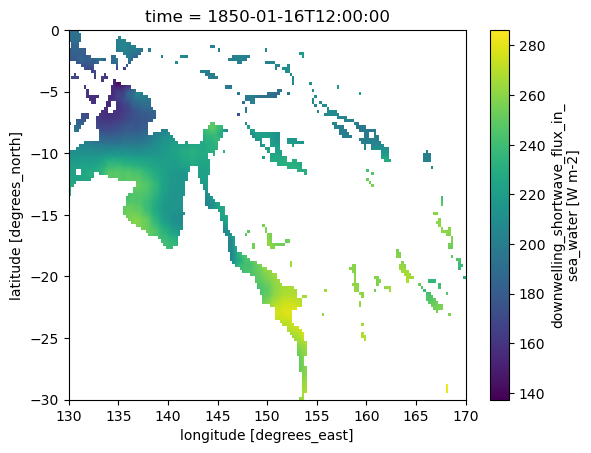

In [25]:
upsampled_rsdo.rsdo.sel(latitude=slice(*cs_lats), longitude=slice(*cs_lons)).plot()  # takes a long time: large area with high resolution

In [28]:
### apply higher-resolution shallow water mask to upsampled rsdo data

# reproject bathymetry mask to rsdo
bathymetry_mask_env = bathymetry_mask.interp(
    longitude=upsampled_rsdo.longitude,
    latitude=upsampled_rsdo.latitude,
    method="nearest"
)

In [29]:
# mask upsampled rsdo data with higher-resolution bathymetry mask
masked_rsdo_hr = upsampled_rsdo.where(~bathymetry_mask_env.isnull())

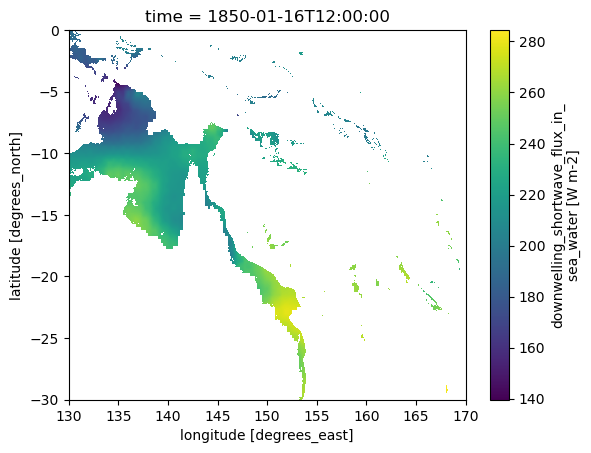

In [30]:
masked_rsdo_hr.rsdo.sel(latitude=slice(*cs_lats), longitude=slice(*cs_lons)).plot()  # takes a long time: large area with high resolution

In [ ]:
### 3. Scaling AUC calculation for high-resolution timeseries: QQQ how to improve efficiency?
lim_par_ds = par_ds

par_lims = []
aucs = []
for t in tqdm(range(len(par_ds.time))):
    valid_mask = ~np.isnan(lim_par_ds.isel(time=t)) & ~np.isnan(reef_ds)
    par_values = lim_par_ds.isel(time=t).values[valid_mask]
    reef_values = reef_ds.values[valid_mask]

    # define thresholds (evenly spaced bins between min and max values)
    lower_thresholds = np.linspace(par_values.min(), par_values.max(), 50)
    upper_thresholds = lower_thresholds.copy()

    best_auc = -np.inf  # initialise as empty
    best_thresholds = (None, None)

    # iterate through all combinations of lower and upper thresholds
    for lower in lower_thresholds:
        for upper in upper_thresholds[upper_thresholds >= lower]:
            # create a mask for the current variable (e.g. PAR) range
            range_mask = (par_values >= lower) & (par_values <= upper)
            
            # calculate true positives (reef cells in range) and false positives (non-reef cells in range)
            TP = np.sum(range_mask & (reef_values == 1))
            FP = np.sum(range_mask & (reef_values == 0))
            FN = np.sum(~range_mask & (reef_values == 1))
            TN = np.sum(~range_mask & (reef_values == 0))
            
            sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
            specificity = TN / (FP + TN) if (FP + TN) > 0 else 0
            # AUC-like metric
            auc_score = sensitivity - (1 - specificity)
            
            # update best thresholds if previous best AUC score beaten
            if auc_score > best_auc:
                best_auc = auc_score
                best_thresholds = (lower, upper)

    # extract best thresholds
    best_lower, best_upper = best_thresholds
    par_lims.append((best_lower, best_upper))
    aucs.append(best_auc)

In [ ]:
### 4. How to connect to `dask` dashboard on ssh server? – ANSWERED
from dask.distributed import Client
client = Client()
client

/maps/rt582/miniforge3/envs/shiftpy/lib/python3.12/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33887 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:33887/status,
Dashboard: http://127.0.0.1:33887/status,Workers: 16
Total threads: 256,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46873,Workers: 16
Dashboard: http://127.0.0.1:33887/status,Total threads: 256
Started: Just now,Total memory: 0.98 TiB
Comm: tcp://127.0.0.1:35035,Total threads: 16
Dashboard: http://127.0.0.1:45683/status,Memory: 62.98 GiB
Nanny: tcp://127.0.0.1:43705,


In [ ]:
client.close()
client.shutdown()
client

In [ ]:
### 5. Best practice for shutting down `dask` clusters?

# Next step: applying same upgrades in upsampling to machine learning algorithm(s)

![desired_xgboost_behaviour](/maps/rt582/coralshift/notebooks/wip/desired_xgboost.jpg)

~~strikethrough~~ sections denote current functionality, with desired improvements in <font color="red">red</font>.